### Ashbah Faisal
### af08271
### HW-8-Clustering

In [13]:
# Q1
import os
os.environ["OMP_NUM_THREADS"] = '1'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler

data = pd.read_csv('baskin_robbins_icecream.csv')

data_cleaned = data.drop(columns=['Flavour', 'Category'])
data_cleaned

,Calories,Total Fat (g),Trans Fat (g),Carbohydrates (g),Sugars (g),Protein (g)
0,160,8.0,0.2,20,16,2.0
1,160,9.0,0.2,19,13,3.0
2,170,9.0,0.3,21,15,3.0
3,120,4.0,0.1,17,16,3.0
4,130,2.0,0.1,26,20,2.0
...,...,...,...,...,...,...
65,200,10.0,0.4,24,21,4.0
66,120,0.5,0.0,27,20,0.1
67,80,1.5,0.0,16,12,1.0
68,160,8.0,0.2,20,16,2.0


In [15]:
#Q2
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_cleaned)
data_scaled[1:5]

array([[0.34615385, 0.15      , 0.4       , 0.24      , 0.375     ,
        0.375     ],
       [0.38461538, 0.15      , 0.6       , 0.32      , 0.45833333,
        0.375     ],
       [0.19230769, 0.06666667, 0.2       , 0.16      , 0.5       ,
        0.375     ],
       [0.23076923, 0.03333333, 0.2       , 0.52      , 0.66666667,
        0.25      ]])

Text(0, 0.5, 'WSS (Within-Cluster Sum of Squares)')

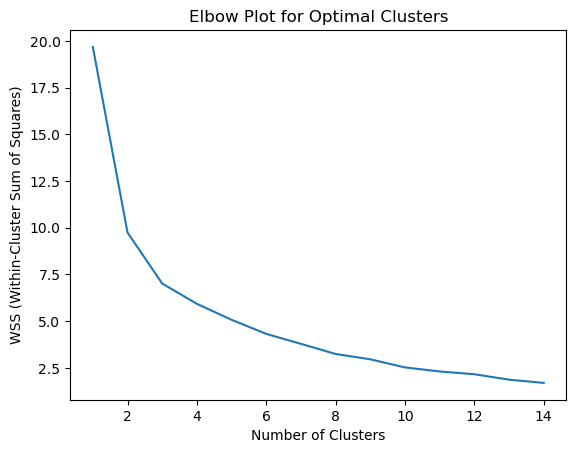

In [17]:
# Q3
import warnings
warnings.filterwarnings('ignore')
wss = []

for i in range(1, 15):
    kmeans = KMeans(n_clusters = i, max_iter = 300, n_init=10, random_state = 99)
    kmeans.fit(data_scaled)
    wss.append(kmeans.inertia_)

# Plotting WSS (Elbow Plot)
plt.plot(range(1, 15), wss)
plt.title('Elbow Plot for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WSS (Within-Cluster Sum of Squares)')



### In this plot, there is a significant drop in WSS from 1 to around 3 clusters, and then the decrease slows down. The "elbow" appears to be around 3 or 4 clusters.This implies that 3 or 4 clusters could be optimal choices for segmenting the dataset effectively without adding unnecessary complexity.

In [19]:
# Q4
kmeans_optimal = KMeans(n_clusters=3, max_iter = 300, random_state=42)
cluster_labels = kmeans_optimal.fit_predict(data_scaled)
print(cluster_labels)
score = silhouette_score(data_scaled, kmeans.labels_, metric='euclidean')
print(score)




[0 0 0 0 0 0 0 0 2 1 0 1 1 2 0 2 0 0 0 1 2 1 0 0 0 2 0 2 2 2 1 0 0 0 2 1 2
 1 0 1 1 0 1 0 0 0 0 1 2 0 0 2 0 2 0 2 2 0 0 2 0 0 1 0 0 1 0 0 0 1]
0.32207928065620084


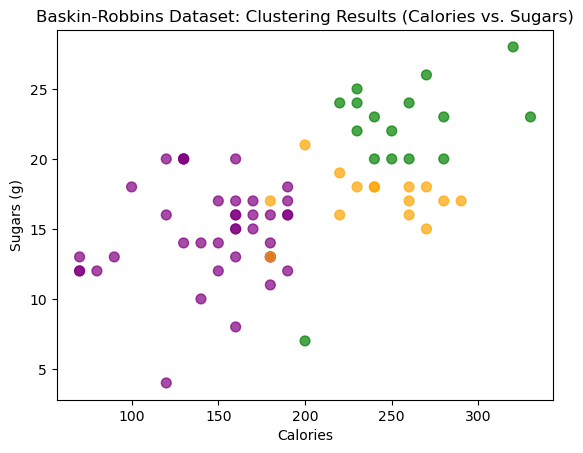

In [21]:
# Q5
colors = np.array(['purple', 'orange', 'green'])  

#plt.figure(figsize=(10, 6))
plt.scatter(data_cleaned['Calories'], data_cleaned['Sugars (g)'], c=colors[cluster_labels], s=50, alpha=0.7)
plt.xlabel('Calories')
plt.ylabel('Sugars (g)')
plt.title("Baskin-Robbins Dataset: Clustering Results (Calories vs. Sugars)")
plt.show()


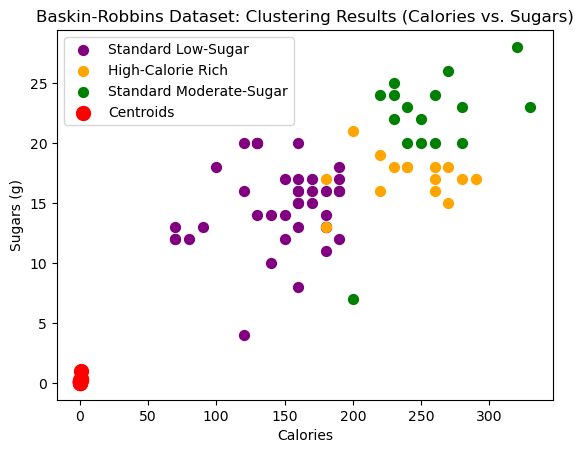

In [22]:
#Q6
plt.scatter(data[cluster_labels == 0]['Calories'], data[cluster_labels == 0]['Sugars (g)'], s=50, c='purple', label='Standard Low-Sugar')
plt.scatter(data[cluster_labels == 1]['Calories'], data[cluster_labels == 1]['Sugars (g)'], s=50, c='orange', label='High-Calorie Rich')
plt.scatter(data[cluster_labels == 2]['Calories'], data[cluster_labels == 2]['Sugars (g)'], s=50, c='green', label='Standard Moderate-Sugar')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:,1], s = 100, c = 'red', label = 'Centroids')

plt.xlabel('Calories')
plt.ylabel('Sugars (g)')
plt.legend()
plt.title("Baskin-Robbins Dataset: Clustering Results (Calories vs. Sugars)")
plt.show()


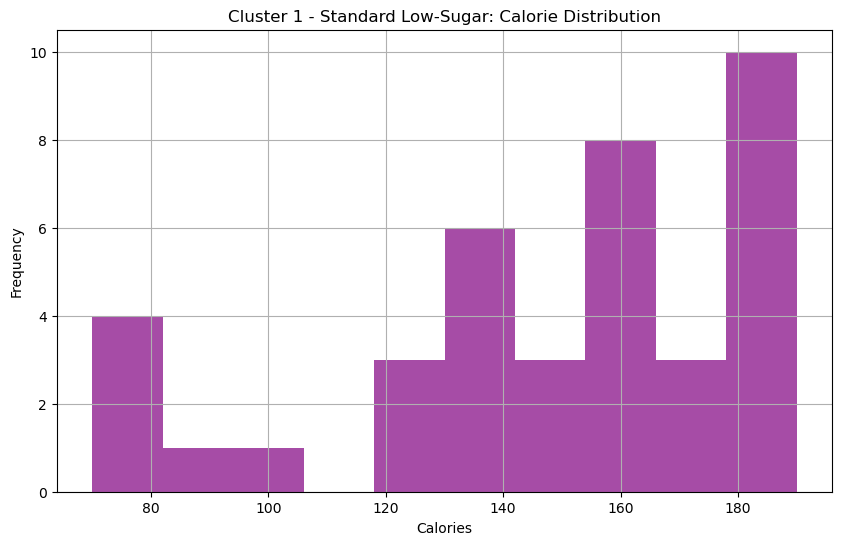

Insight for Cluster 1 - Standard Low-Sugar:
This cluster has a lower calorie distribution, generally falling below 150 calories. It represents options that balance flavor with a lower sugar level, appealing to health-conscious customers.


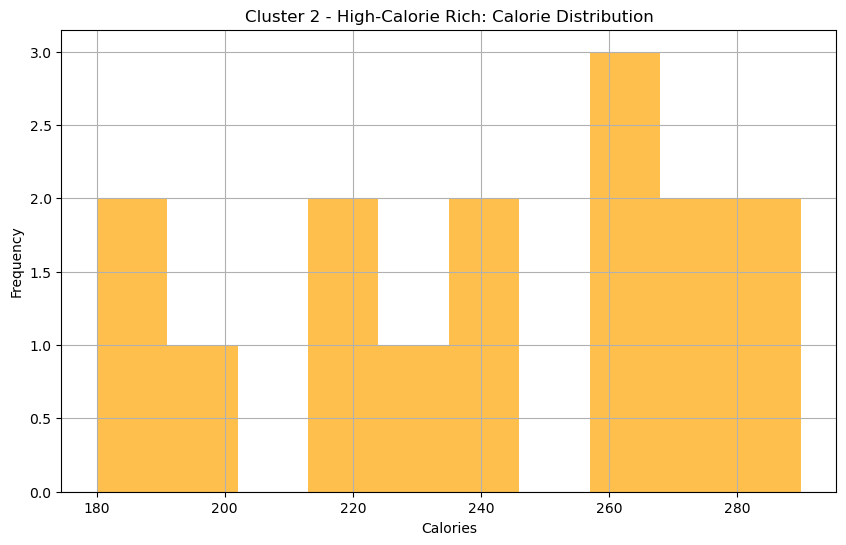

Insight for Cluster 2 - High-Calorie Rich:
This cluster has a significantly higher calorie range, with most items above 200 calories. These are likely indulgent, richer flavors appealing to customers prioritizing taste and richness over lower calories.


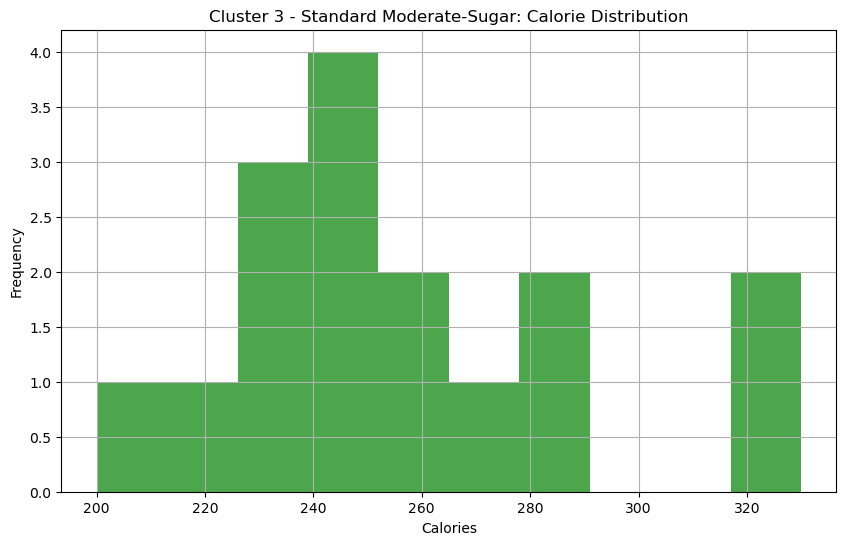

Insight for Cluster 3 - Standard Moderate-Sugar:
This cluster provides a moderate calorie range, generally between 150-180 calories. It offers a balanced approach with a slightly higher sugar level, appealing to customers who want something sweet but not overly indulgent.


In [24]:
#Q7
C1 = data.iloc[cluster_labels == 0, :]
C2 = data.iloc[cluster_labels == 1, :]
C3 = data.iloc[cluster_labels == 2, :]

plt.figure(figsize=(10, 6))
C1['Calories'].hist(color='purple', bins=10, alpha=0.7)
plt.title("Cluster 1 - Standard Low-Sugar: Calorie Distribution")
plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.show()


print("Insight for Cluster 1 - Standard Low-Sugar:")
print("This cluster has a lower calorie distribution, generally falling below 200 calories. It represents options that balance flavor with a lower sugar level, appealing to health-conscious customers.")


plt.figure(figsize=(10, 6))
C2['Calories'].hist(color='orange', bins=10, alpha=0.7)
plt.title("Cluster 2 - Standard Moderate-Sugar: Calorie Distribution") 
plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.show()

print("Insight for Cluster 2 - Standard Moderate-Sugar:")
print("This cluster provides a moderate calorie range, generally between 180-300 calories. It offers a balanced approach with a slightly higher sugar level, appealing to customers who want something sweet but not overly indulgent.")


plt.figure(figsize=(10, 6))
C3['Calories'].hist(color='green', bins=10, alpha=0.7)
plt.title("Cluster 3 - High-Calorie Rich: Calorie Distribution")
plt.xlabel("Calories")
plt.ylabel("Frequency")
plt.show()

print("Insight for Cluster 3 - High-Calorie Rich:")
print("This cluster has a significantly higher calorie range, with most items above 200-340 calories. These are likely indulgent, richer flavors appealing to customers prioritizing taste and richness over lower calories.")

### Q8
### Cluster 1 - "Calorie-Conscious"
### Cluster 2 - "Indulgence Seekers"
### Cluster 3 - "Balanced Treats"